In [1]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os
os.environ['S3_ACCESS'] = 'c490f17bdb784fa08f4d11836ee18e48'
os.environ['S3_SECRET'] = 'e4b65e27b3734d0d96ce6038586ef43f'
os.environ['S3_ENDPOINT'] = 's3.gra.cloud.ovh.net'
os.environ['S3_REGION'] = 'GRA'
s3_connection = {
    's3_access':os.environ['S3_ACCESS'],
    's3_secret':os.environ['S3_SECRET'],
    's3_endpoint': os.environ['S3_ENDPOINT'],
    's3_region':os.environ['S3_REGION']
}

from baskervillehall.baskervillehall_isolation_forest import ModelType
from baskervillehall.model_io import ModelIO

2025-12-09 14:17:37.874923: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-09 14:17:37.882089: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-09 14:17:37.896915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765289857.920194      77 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765289857.926777      77 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765289857.947685      77 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import time
import matplotlib.mlab as mlab
from baskervillehall.baskervillehall_isolation_forest import ModelType
import pandas as pd
from sklearn.preprocessing import StandardScaler
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest
from baskervillehall.baskervillehall_isolation_forest import ModelType
from baskervillehall.baskerville_classifier import BaskervilleClassifier

In [4]:
import logging
import sys

logger = logging.getLogger("bask")
logger.setLevel(logging.DEBUG)

handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.DEBUG)

formatter = logging.Formatter(
    "%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    "%H:%M:%S"
)
handler.setFormatter(formatter)

logger.addHandler(handler)
logger.propagate = False   # VERY IMPORTANT in Jupyter



In [5]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
partitions = {
    'vytoki.net': 0,
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'btselem.org': 0,
    'verafiles.org': 1,
    'telegraf.in.ua': 2,
    'gubernia.com': 1,
    'informator.ua': 0,
    'culturesofresistance.org': 2,
    'zmina.info': 1,
    'memex.craphound.com': 2,
    'greencubator.info': 0
}
datetime_format = '%Y-%m-%d %H:%M:%S'
topic = 'BASKERVILLEHALL_4'

In [ ]:
features = [
      'request_rate', 'post_rate', 'request_interval_average',
      'request_interval_std', 'response4xx_to_request_ratio',
      'response5xx_to_request_ratio', 'top_page_to_request_ratio',
      'unique_path_rate', 'unique_path_to_request_ratio',
      'unique_query_rate', 
      'entropy', 'num_requests', 'duration', 'edge_count', 
      'num_ciphers', 
      'ua_score',
      'odd_hour', 
      'fingerprints_score',
      'interval_cv', 'interval_consistency',
      'rate_499',
      'valid_browser_ciphers', 
      'weak_cipher', 
      'headless_ua', 
      'short_ua',
      # REMOVED threshold features (circular reasoning):
      # 'extreme_request_rate', 'high_request_rate',
      # These features don't work because:
      # - WordPress sites have high rate due to parallel resource loading
      # - Training data was contaminated with "rate > 100" labeling rule
      # - Model learned: high rate → HUMAN (opposite of intended!)
  ]

categorical_features=[
            'cipher_type',
]


In [ ]:
"""
Improved session labeling logic for training bot detection classifier.

Note: Expects kafka_url and topic to be defined in the calling scope.
"""


def read_sessions_with_labels(size=1000):
    from kafka import KafkaConsumer, TopicPartition
    import json
    import time
    import sys
    import math
    from collections import defaultdict
    sys.path.insert(0, '/Users/almaz/equalitie/baskervillehall/src')
    from baskervillehall.baskerville_rules import ua_score as calculate_ua_score, is_valid_browser_ciphers, normalize_cipher

    def calculate_entropy(requests):
        """Calculate Shannon entropy from URL distribution."""
        if not requests:
            return 0.0
        url_counts = defaultdict(int)
        for req in requests:
            url = req.get('url', '/')
            query = req.get('query', '')
            full_url = url + ('?' + query if query else '')
            url_counts[full_url] += 1
        total = sum(url_counts.values())
        if total == 0:
            return 0.0
        H = 0.0
        for count in url_counts.values():
            if count == 0:
                continue
            p = count / total
            H -= p * math.log(p, 2)
        return H

    consumer = KafkaConsumer(bootstrap_servers=kafka_url)

    print(f'Reading from kafka.')
    time_now = int(time.time())
    sessions = []
    labels = []

    consumer.assign([TopicPartition(topic, p) for p in range(9)])
    consumer.seek_to_beginning()
    complete = False
    hosts = set()

    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=100)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes:.2f} minutes. Topic offset is too close to the current time...')
                    complete = True
                    break

                if message.value is None or message.key is None:
                    continue

                s = json.loads(message.value.decode("utf-8"))

                if s.get('asset_only', False):
                    continue
                if s.get('primary_session', False):
                    continue  # Skip primary sessions - rule-based, не для ML
                if s.get('verified_bot', False):
                    continue  # Skip verified bots (Googlebot, etc)

                # Skip очень короткие сессии (<8 requests) - слишком мало данных для анализа
                if len(s.get('requests', [])) < 8:
                    continue

                # Пересчитываем ua_score, valid_browser_ciphers и cipher_type заново
                user_agent = s.get('ua', '')
                s['ua_score'] = calculate_ua_score(user_agent)

                ciphers = s.get('ciphers', [])
                s['valid_browser_ciphers'] = is_valid_browser_ciphers(ciphers)

                # Вычисляем cipher_type из cipher
                cipher = s.get('cipher', '')
                if not cipher and ciphers:
                    cipher = ciphers[0] if isinstance(ciphers, list) else ciphers
                s['cipher_type'] = normalize_cipher(cipher)

                # Вычисляем entropy и request_rate для проверки правил
                requests = s.get('requests', [])
                entropy = calculate_entropy(requests)
                num_requests = len(requests)
                duration = s.get('duration', 1)
                request_rate = (num_requests / duration * 60) if duration > 0 else 0

                # ==========================================
                # RULE-BASED BOT DETECTION
                # ==========================================
                # ВАЖНО: НЕ используем request_rate как единственный критерий!
                # WordPress сайты имеют high rate из-за параллельной загрузки ресурсов

                is_obvious_bot = (
                    s.get('headless_ua', False) or
                    s.get('ai_bot_ua', False) or
                    s.get('bot_ua', False) or
                    # Entropy = 0 только для длинных сессий
                    (entropy == 0 and num_requests > 15) or
                    # Низкая entropy + высокий rate (комбинация!) - скорее всего скрейпер
                    (entropy < 1.0 and request_rate > 200 and num_requests > 15) or
                    # Очень низкая entropy
                    (entropy < 0.5 and num_requests > 10)
                )

                # УДАЛИЛИ эти правила (circular reasoning):
                # - request_rate > 100  ← Люди на WordPress тоже имеют high rate!
                # - weak_cipher + request_rate > 50

                if is_obvious_bot:
                    label = 1
                    hosts.add(s.get('host', 'unknown'))
                    sessions.append(s)
                    labels.append(label)

                    if len(sessions) == 1:
                        print(f'First session start = {s["start"]} end = {s["end"]}')

                    if len(sessions) >= size:
                        complete = True
                        break
                    if len(sessions) % 10000 == 0:
                        print(f'{len(sessions)} sessions collected', s['end'], message.timestamp)
                    continue

                # ==========================================
                # HUMAN vs BOT (используем session pipeline's flags)
                # ==========================================

                human = s.get('human', False)

                if human:
                    # Session pipeline пометил как human - доверяем этому
                    # Проверяем только если прошел challenge с высоким bot_score
                    if s.get('passed_challenge', False):
                        bot_score = s.get('bot_score', 0)
                        # Умный бот: прошел challenge но имеет высокий bot_score
                        if bot_score > 0.5:
                            # Дополнительная проверка: низкая entropy?
                            if entropy < 2.0:
                                label = 1  # Умный бот с низкой вариативностью
                            else:
                                label = 0  # Скорее всего человек
                        else:
                            label = 0  # Человек
                    else:
                        # Не прошел challenge, но помечен как human
                        # Берем только уверенные примеры людей
                        good_ua = s.get('ua_score', 1) < 0.2
                        has_entropy = entropy > 1.5
                        valid_ciphers = s.get('valid_browser_ciphers', False)
                        
                        # Требуем хорошие признаки
                        if good_ua and has_entropy and valid_ciphers:
                            label = 0
                        else:
                            continue  # Неуверенный случай - пропускаем
                else:
                    # Помечен как не-человек session pipeline
                    # Проверяем дополнительные признаки
                    if entropy < 2.0 or s.get('ua_score', 0) > 0.3:
                        label = 1
                    else:
                        # Граничный случай - пропускаем
                        continue

                if len(sessions) == 0:
                    print(f'First session start = {s["start"]} end = {s["end"]}')

                hosts.add(s.get('host', 'unknown'))
                sessions.append(s)
                labels.append(label)

                if len(sessions) >= size:
                    complete = True
                    break

                if len(sessions) % 10000 == 0:
                    print(f'{len(sessions)} sessions collected', s['end'], message.timestamp)

    print(f'\nTotal hosts: {len(hosts)}')
    print(f'Total sessions: {len(sessions)}')
    print(f'Total labels: {len(labels)}')

    # Check consistency
    if len(sessions) != len(labels):
        print(f'WARNING: Mismatch! sessions={len(sessions)}, labels={len(labels)}')
        min_len = min(len(sessions), len(labels))
        sessions = sessions[:min_len]
        labels = labels[:min_len]
        print(f'Truncated to {min_len}')

    print(f'Bots (label=1): {sum(labels)}')
    print(f'Humans (label=0): {len(labels) - sum(labels)}')

    if len(labels) > 0:
        bot_ratio = sum(labels) / len(labels)
        print(f'Bot ratio: {bot_ratio:.2%}')

    return sessions, labels, hosts


In [22]:
sessions = None
sessions, labels, hosts = read_sessions_with_labels(size=70000)
print(len(hosts))

Reading from kafka.
First session start = 2025-11-29 10:29:00 end = 2025-11-29 10:29:12
10000 sessions collected 2025-12-01 17:23:35 1764609822690
20000 sessions collected 2025-11-27 15:55:58 1764258963672
30000 sessions collected 2025-11-30 16:41:38 1764520906388
40000 sessions collected 2025-12-01 22:40:23 1764628827452
50000 sessions collected 2025-12-02 00:10:44 1764634252447
60000 sessions collected 2025-11-30 06:13:49 1764483239813

Total hosts: 496
Total sessions: 70000
Total labels: 70000
Bots (label=1): 15129
Humans (label=0): 54871
Bot ratio: 21.61%
496


In [9]:
num_smart_bots = 0
for s in sessions:
    if s['bot_score'] > 0.2 and s['bot_score_top_factor'] != 'no_payload' \
      and s['bot_score_top_factor'] != 'err_payload':
        num_smart_bots += 1
        # print('\n@@@@@@@@@@@@@@@@@@@@@@')
        # print(s['host'], s['bot_score'], s['bot_score_top_factor'], s['passed_challenge'])
        # for r in s['requests']:
        #     print(r['ts'], r['url'])
        # break
print(f'num_smart_bots = {num_smart_bots}')

num_smart_bots = 1457


In [10]:
labels = np.array(labels)

In [11]:
model = BaskervilleClassifier(
    n_estimators=1000, 
    learning_rate=0.1,
    features=features,
    categorical_features=categorical_features,
    logger=logger
)
model.fit(sessions, labels)

14:18:36 [INFO] bask: Extracting features...
14:20:09 [INFO] bask: Fitting Baskerville classifier...
14:20:09 [INFO] bask: Preparing dataset...
14:20:09 [INFO] bask: Training model...
[0]	train-aucpr:0.96248+0.00178	test-aucpr:0.96101+0.00342
[1]	train-aucpr:0.96927+0.00118	test-aucpr:0.96792+0.00265
[2]	train-aucpr:0.97075+0.00253	test-aucpr:0.96930+0.00318
[3]	train-aucpr:0.97651+0.00115	test-aucpr:0.97603+0.00119
[4]	train-aucpr:0.98230+0.00069	test-aucpr:0.98162+0.00160
[5]	train-aucpr:0.98427+0.00096	test-aucpr:0.98378+0.00151
[6]	train-aucpr:0.98552+0.00109	test-aucpr:0.98448+0.00125
[7]	train-aucpr:0.98686+0.00096	test-aucpr:0.98562+0.00131
[8]	train-aucpr:0.98787+0.00101	test-aucpr:0.98708+0.00133
[9]	train-aucpr:0.98925+0.00081	test-aucpr:0.98830+0.00121
[10]	train-aucpr:0.98991+0.00090	test-aucpr:0.98887+0.00133
[11]	train-aucpr:0.99143+0.00059	test-aucpr:0.99029+0.00070
[12]	train-aucpr:0.99165+0.00054	test-aucpr:0.99075+0.00063
[13]	train-aucpr:0.99208+0.00036	test-aucpr:0.

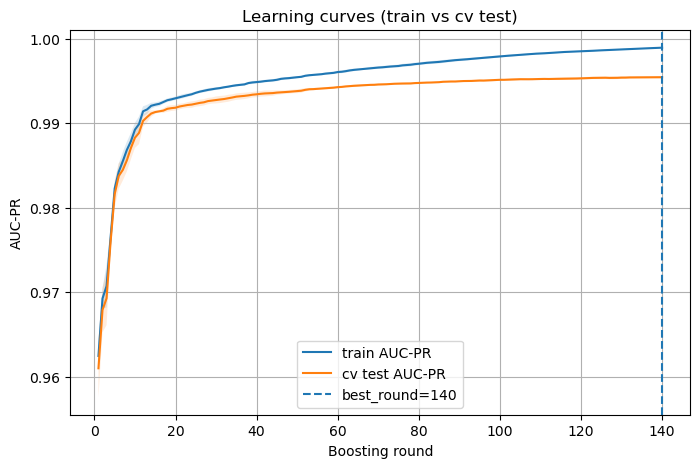

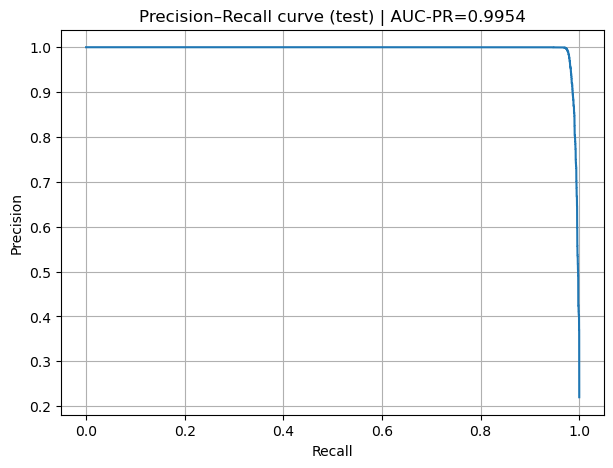

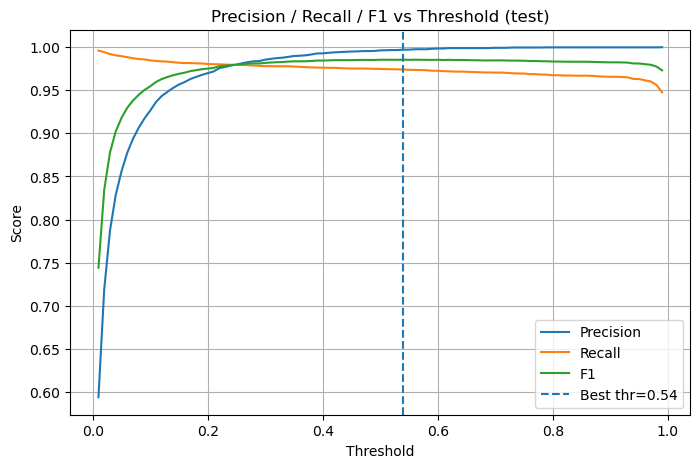

,feature,importance
15,ua_score,2541.586426
18,interval_cv,207.942322
23,cipher_type,144.427643
21,short_ua,47.682419
14,num_ciphers,38.201439
5,response5xx_to_request_ratio,37.781593
9,unique_query_rate,29.264648
11,num_requests,25.858728
7,unique_path_rate,25.589394
6,top_page_to_request_ratio,21.346567


In [12]:
model.plot_learning_curves()
model.plot_pr_curve()
model.plot_threshold_curves()

imp = model.get_feature_importance("gain", top_n=20)
display(imp)

In [13]:
y_pred, bot_score, shap_vals, X_df = model.transform(sessions[:100], use_shapley=False)

14:25:03 [INFO] bask: [transform] Features shape: (100, 28)
14:25:03 [INFO] bask: [transform] Features stats: min=0.0000, max=780.0000, mean=17.7866, std=58.8167
14:25:03 [INFO] bask: [transform] First session features (first 10): [3.2000000e+02 0.0000000e+00 1.9047619e-01 7.3153769e-01 0.0000000e+00
 0.0000000e+00 1.5625000e-02 3.2000000e+02 1.0000000e+00 1.1500000e+02]
14:25:03 [INFO] bask: [_bot_score_from_proba] Raw proba: min=0.000233, max=0.999887, mean=0.493301, std=0.487234, threshold=0.540000
14:25:03 [INFO] bask: [_bot_score_from_proba] Final scores: min=1, max=98, mean=50.0, unique_values=14
14:25:03 [INFO] bask: y_proba stats: min=0.0002, max=0.9999, mean=0.4933, median=0.1042
14:25:03 [INFO] bask: bot_score stats: min=1, max=98, mean=50.0, median=85.0
14:25:03 [INFO] bask: threshold=0.5400


In [14]:
y_pred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0])

In [15]:
bot_score

array([95, 98,  1,  1, 82, 97,  1,  1, 97,  1, 97,  1, 98,  1, 96, 97, 98,
        1, 93,  1, 98,  1,  1, 98, 98,  1,  1,  1,  1, 98, 98, 96,  1,  1,
        1, 88, 98, 98, 98, 95,  1, 97,  1, 97,  1,  1,  1, 96,  1,  1,  1,
       98, 94, 73, 91,  1,  1, 98, 97, 98, 98, 98,  1,  1,  1, 97, 96,  1,
       93, 98,  1, 90,  1, 97, 98, 97, 98,  1,  1, 95, 92, 90,  1, 98,  1,
       91,  1, 88,  1,  1,  1,  1,  1, 98,  1,  1,  1, 89,  1, 98])

In [17]:
X_df['high_request_rate'].min(), X_df['high_request_rate'].max()

(0.0, 1.0)

In [ ]:
X_df['entropy'].hist()

Error in callback <function flush_figures at 0x7f522f1d2de0> (for post_execute):



KeyboardInterrupt



In [ ]:
# Compare: high-rate HUMANS vs high-rate BOTS
print("="*80)
print("COMPARING HIGH-RATE HUMANS vs HIGH-RATE BOTS")
print("="*80)

# High-rate bots (rate > 300)
high_rate_bot_indices = []
for i in range(len(sessions)):
    if labels[i] == 1:  # Bot
        rate = X_df_all['request_rate'].values[i]
        if rate > 300:
            high_rate_bot_indices.append(i)

print(f"\nFound {len(high_rate_bot_indices)} BOTS with rate > 300 req/min")

if len(high_rate_bot_indices) > 0:
    print(f"\n{'='*80}")
    print("ANALYZING FIRST HIGH-RATE BOT:")
    print(f"{'='*80}")
    
    idx = high_rate_bot_indices[0]
    s = sessions[idx]
    rate = X_df_all['request_rate'].values[idx]
    entropy = X_df_all['entropy'].values[idx]
    num_requests = len(s['requests'])
    duration = s['duration']
    
    print(f"\nSession #{idx}:")
    print(f"  Host: {s.get('host', 'unknown')}")
    print(f"  Request Rate: {rate:.1f} req/min")
    print(f"  Num Requests: {num_requests}")
    print(f"  Duration: {duration:.1f}s")
    print(f"  Entropy: {entropy:.2f}")
    print(f"  UA: {s.get('ua', '')[:80]}")
    print(f"  Valid Browser Ciphers: {s.get('valid_browser_ciphers', False)}")
    print(f"  Headless UA: {s.get('headless_ua', False)}")
    print(f"  Bot UA: {s.get('bot_ua', False)}")
    
    # Count request types
    url_counts = {}
    content_types = {}
    
    for r in s['requests']:
        url = r.get('url', '/')
        url_counts[url] = url_counts.get(url, 0) + 1
        
        ctype = r.get('type', 'text/html')
        content_types[ctype] = content_types.get(ctype, 0) + 1
    
    print(f"\n  Content Types:")
    for ctype, count in sorted(content_types.items(), key=lambda x: -x[1])[:5]:
        print(f"    {ctype}: {count} ({count/num_requests*100:.1f}%)")
    
    print(f"\n  Top URLs (by frequency):")
    for url, count in sorted(url_counts.items(), key=lambda x: -x[1])[:10]:
        print(f"    {count:3d}x {url[:70]}")
    
    print(f"\n  Unique URLs: {len(url_counts)} ({len(url_counts)/num_requests*100:.1f}%)")
    
    max_same_url = max(url_counts.values())
    print(f"  Max same URL: {max_same_url} ({max_same_url/num_requests*100:.1f}%)")
    
    if max_same_url / num_requests > 0.3:
        print(f"  ⚠️  REPETITIVE: {max_same_url/num_requests*100:.1f}% requests to same URL")

# Compare statistics
print(f"\n{'='*80}")
print("STATISTICAL COMPARISON:")
print(f"{'='*80}")

# Get all high-rate sessions
high_rate_humans = []
high_rate_bots = []

for i in range(len(sessions)):
    rate = X_df_all['request_rate'].values[i]
    if rate > 300:
        entropy = X_df_all['entropy'].values[i]
        num_requests = len(sessions[i]['requests'])
        
        # Count unique URLs
        url_counts = {}
        for r in sessions[i]['requests']:
            url = r.get('url', '/')
            url_counts[url] = url_counts.get(url, 0) + 1
        
        unique_ratio = len(url_counts) / num_requests if num_requests > 0 else 0
        max_same = max(url_counts.values()) if url_counts else 0
        repetition_ratio = max_same / num_requests if num_requests > 0 else 0
        
        stats = {
            'rate': rate,
            'entropy': entropy,
            'unique_ratio': unique_ratio,
            'repetition_ratio': repetition_ratio
        }
        
        if labels[i] == 0:
            high_rate_humans.append(stats)
        else:
            high_rate_bots.append(stats)

print(f"\nHIGH-RATE HUMANS (n={len(high_rate_humans)}):")
if high_rate_humans:
    print(f"  Mean entropy: {np.mean([s['entropy'] for s in high_rate_humans]):.2f}")
    print(f"  Mean unique_ratio: {np.mean([s['unique_ratio'] for s in high_rate_humans]):.2f}")
    print(f"  Mean repetition_ratio: {np.mean([s['repetition_ratio'] for s in high_rate_humans]):.2f}")

print(f"\nHIGH-RATE BOTS (n={len(high_rate_bots)}):")
if high_rate_bots:
    print(f"  Mean entropy: {np.mean([s['entropy'] for s in high_rate_bots]):.2f}")
    print(f"  Mean unique_ratio: {np.mean([s['unique_ratio'] for s in high_rate_bots]):.2f}")
    print(f"  Mean repetition_ratio: {np.mean([s['repetition_ratio'] for s in high_rate_bots]):.2f}")

print(f"\n{'='*80}")
print("CONCLUSION:")
print(f"{'='*80}")
print("Key differences:")
print("  - HUMANS: high unique_ratio (0.9-1.0), low repetition")
print("  - BOTS: low unique_ratio, high repetition OR low entropy")
print("\nThreshold features alone are NOT enough!")
print("Need combination: high_rate + (low_entropy OR high_repetition)")


In [ ]:
# Check WHY high-rate sessions are labeled as bots
print("="*80)
print("WHY ARE HIGH-RATE SESSIONS LABELED AS BOTS?")
print("="*80)

# Analyze the first high-rate "bot"
idx = 275  # From previous analysis
s = sessions[idx]

print(f"\nSession #{idx} (labeled as BOT):")
print(f"  Host: {s.get('host', 'unknown')}")
print(f"  Request Rate: {X_df_all['request_rate'].values[idx]:.1f} req/min")
print(f"  Entropy: {X_df_all['entropy'].values[idx]:.2f}")
print(f"  Num Requests: {len(s['requests'])}")
print(f"  Duration: {s['duration']:.1f}s")

print(f"\n  FLAGS from session data:")
print(f"    human: {s.get('human', False)}")
print(f"    bad_bot: {s.get('bad_bot', False)}")
print(f"    passed_challenge: {s.get('passed_challenge', False)}")
print(f"    bot_score: {s.get('bot_score', -1):.2f}")
print(f"    headless_ua: {s.get('headless_ua', False)}")
print(f"    bot_ua: {s.get('bot_ua', False)}")
print(f"    ai_bot_ua: {s.get('ai_bot_ua', False)}")
print(f"    weak_cipher: {s.get('weak_cipher', False)}")
print(f"    valid_browser_ciphers: {s.get('valid_browser_ciphers', False)}")

print(f"\n  Labeling logic would trigger on:")

# Check labeling rules from read_sessions_with_labels
num_requests = len(s['requests'])
entropy = X_df_all['entropy'].values[idx]
request_rate = X_df_all['request_rate'].values[idx]

checks = []
if s.get('headless_ua', False):
    checks.append("headless_ua")
if s.get('ai_bot_ua', False):
    checks.append("ai_bot_ua")
if s.get('bot_ua', False):
    checks.append("bot_ua")
if entropy == 0 and num_requests > 15:
    checks.append(f"entropy=0 and num_requests>{15}")
if s.get('weak_cipher', False) and request_rate > 50:
    checks.append(f"weak_cipher and rate>{50}")
if request_rate > 100:
    checks.append(f"rate > 100 ← THIS ONE!")
if entropy < 0.5 and request_rate > 80 and num_requests > 10:
    checks.append(f"entropy<0.5 and rate>80")
if entropy < 1.0 and request_rate > 120 and num_requests > 10:
    checks.append(f"entropy<1.0 and rate>120")

if not checks:
    if not s.get('human', False):
        checks.append("human=False (default bot)")
    elif s.get('passed_challenge', False):
        if s.get('bot_score', 0) > 0.3:
            checks.append(f"passed_challenge but bot_score={s.get('bot_score', 0):.2f}>0.3")
    else:
        # Check human criteria
        good_ua = s.get('ua_score', 1) < 0.15
        has_entropy = entropy > 1.5
        reasonable_rate = request_rate < 50
        checks.append(f"Doesn't meet human criteria (ua_score={s.get('ua_score', 1):.2f}, entropy={entropy:.2f}, rate={request_rate:.1f})")

print(f"    {', '.join(checks) if checks else 'NONE - labeling error?'}")

# Check multiple high-rate bots
print(f"\n{'='*80}")
print("LABELING REASONS FOR ALL HIGH-RATE BOTS:")
print(f"{'='*80}")

high_rate_bot_indices = []
for i in range(len(sessions)):
    if labels[i] == 1:  # Bot
        rate = X_df_all['request_rate'].values[i]
        if rate > 300:
            high_rate_bot_indices.append(i)

reason_counts = {
    'rate > 100': 0,
    'entropy issues': 0,
    'bot_ua flags': 0,
    'weak_cipher': 0,
    'human=False': 0,
    'other': 0
}

for idx in high_rate_bot_indices[:100]:  # Check first 100
    s = sessions[idx]
    request_rate = X_df_all['request_rate'].values[idx]
    entropy = X_df_all['entropy'].values[idx]
    num_requests = len(s['requests'])
    
    if s.get('headless_ua', False) or s.get('bot_ua', False) or s.get('ai_bot_ua', False):
        reason_counts['bot_ua flags'] += 1
    elif request_rate > 100:
        reason_counts['rate > 100'] += 1
    elif entropy < 0.5 or (entropy < 1.0 and request_rate > 120):
        reason_counts['entropy issues'] += 1
    elif s.get('weak_cipher', False) and request_rate > 50:
        reason_counts['weak_cipher'] += 1
    elif not s.get('human', False):
        reason_counts['human=False'] += 1
    else:
        reason_counts['other'] += 1

print(f"\nLabeling reasons (first 100 high-rate bots):")
for reason, count in sorted(reason_counts.items(), key=lambda x: -x[1]):
    print(f"  {reason:20s}: {count:3d} ({count/min(100, len(high_rate_bot_indices))*100:5.1f}%)")

print(f"\n{'='*80}")
print("CONCLUSION:")
print(f"{'='*80}")
print("If most high-rate bots are labeled ONLY because 'rate > 100',")
print("then the labeling logic is CIRCULAR:")
print("  1. Label as bot because rate > 100")
print("  2. Train model to detect bots")
print("  3. Model learns: high rate → human (because real humans also have high rate!)")
print("\nSOLUTION: Remove 'rate > 100' rule from labeling!")
print("Only label as bot if OTHER evidence (entropy, ua, repetition)")


In [ ]:
# Analyze interval_consistency distribution
print("="*80)
print("INTERVAL_CONSISTENCY ANALYSIS")
print("="*80)

if 'sessions' in globals() and 'labels' in globals():
    # Recalculate if needed
    if 'X_df_all' not in globals():
        y_pred_all, bot_score_all, _, X_df_all = model.transform(sessions, use_shapley=False)
    
    bot_indices = labels == 1
    human_indices = labels == 0
    
    consistency_bots = X_df_all['interval_consistency'].values[bot_indices]
    consistency_humans = X_df_all['interval_consistency'].values[human_indices]
    
    print(f"\nBOTS (n={sum(bot_indices)}):")
    print(f"  Mean interval_consistency: {np.mean(consistency_bots):.3f}")
    print(f"  Median: {np.median(consistency_bots):.3f}")
    print(f"  > 0.8: {sum(consistency_bots > 0.8)} ({sum(consistency_bots > 0.8)/len(consistency_bots)*100:.1f}%)")
    print(f"  > 0.85: {sum(consistency_bots > 0.85)} ({sum(consistency_bots > 0.85)/len(consistency_bots)*100:.1f}%)")
    
    print(f"\nHUMANS (n={sum(human_indices)}):")
    print(f"  Mean interval_consistency: {np.mean(consistency_humans):.3f}")
    print(f"  Median: {np.median(consistency_humans):.3f}")
    print(f"  > 0.8: {sum(consistency_humans > 0.8)} ({sum(consistency_humans > 0.8)/len(consistency_humans)*100:.1f}%)")
    print(f"  > 0.85: {sum(consistency_humans > 0.85)} ({sum(consistency_humans > 0.85)/len(consistency_humans)*100:.1f}%)")
    
    # Plot
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].hist(consistency_bots, bins=50, alpha=0.7, color='red', edgecolor='black')
    axes[0].axvline(0.8, color='orange', linestyle='--', linewidth=2, label='0.8 threshold')
    axes[0].axvline(0.87, color='darkred', linestyle='--', linewidth=2, label='Your bot: 0.87')
    axes[0].set_xlabel('interval_consistency')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Interval Consistency - BOTS')
    axes[0].legend()
    
    axes[1].hist(consistency_humans, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1].axvline(0.8, color='orange', linestyle='--', linewidth=2, label='0.8 threshold')
    axes[1].axvline(0.87, color='darkred', linestyle='--', linewidth=2, label='Your bot: 0.87')
    axes[1].set_xlabel('interval_consistency')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Interval Consistency - HUMANS')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Check if high consistency + high rate is distinctive
    print(f"\n{'='*80}")
    print("HIGH CONSISTENCY + HIGH RATE COMBINATION:")
    print(f"{'='*80}")
    
    request_rate_bots = X_df_all['request_rate'].values[bot_indices]
    request_rate_humans = X_df_all['request_rate'].values[human_indices]
    
    # Your bot pattern: consistency > 0.85 AND rate > 300
    bot_match = sum((consistency_bots > 0.85) & (request_rate_bots > 300))
    human_match = sum((consistency_humans > 0.85) & (request_rate_humans > 300))
    
    print(f"\nConsistency > 0.85 AND rate > 300:")
    print(f"  Bots: {bot_match} ({bot_match/len(consistency_bots)*100:.1f}%)")
    print(f"  Humans: {human_match} ({human_match/len(consistency_humans)*100:.1f}%)")
    
    if human_match / len(consistency_humans) < 0.01:
        print(f"\n✓ GOOD: This combination catches bots with <1% false positives")
        print(f"  Could add rule: IF consistency > 0.85 AND rate > 300 → BOT")
    else:
        print(f"\n⚠️  Not reliable: {human_match/len(consistency_humans)*100:.1f}% false positives")
    
    # Try different thresholds
    print(f"\n{'='*80}")
    print("THRESHOLD OPTIMIZATION:")
    print(f"{'='*80}")
    
    for cons_thresh in [0.75, 0.80, 0.85, 0.90]:
        for rate_thresh in [200, 300, 400]:
            bot_match = sum((consistency_bots > cons_thresh) & (request_rate_bots > rate_thresh))
            human_match = sum((consistency_humans > cons_thresh) & (request_rate_humans > rate_thresh))
            
            if bot_match > 0:
                precision = bot_match / (bot_match + human_match) if (bot_match + human_match) > 0 else 0
                recall = bot_match / len(consistency_bots)
                fpr = human_match / len(consistency_humans)
                
                print(f"consistency > {cons_thresh:.2f} AND rate > {rate_thresh}:")
                print(f"  Catches {bot_match} bots ({recall*100:.1f}%), {human_match} humans (FPR={fpr*100:.2f}%), precision={precision*100:.1f}%")
else:
    print("No data loaded. Run the training cells first.")


In [19]:
model_io.save(model, 
              'anton/clearinghouse/models11_classifier',
              'global', 
                model_type=ModelType.GENERIC)

14:25:43 [INFO] bask: Model for host global saved into anton/clearinghouse/models11_classifier/global/generic/2025_12_09___14_25.pkl


In [15]:
m1 = model_io.load(
    'anton/baslervillehall/models59_classifier', 
    'global', 
    model_type=ModelType.GENERIC
)


In [21]:

# Analyze num_languages distribution
import numpy as np
from collections import Counter

bot_num_languages = []
human_num_languages = []

for i, session in enumerate(sessions):
    num_lang = session.get('num_languages', 0)
    if labels[i] == 1:  # Bot
        bot_num_languages.append(num_lang)
    else:  # Human
        human_num_languages.append(num_lang)

print(f"\n{'='*80}")
print("NUM_LANGUAGES DISTRIBUTION ANALYSIS")
print(f"{'='*80}")

# Distribution
bot_counts = Counter(bot_num_languages)
human_counts = Counter(human_num_languages)

print(f"\nBOTS (label=1): {len(bot_num_languages)} sessions")
print(f"  Mean: {np.mean(bot_num_languages):.2f}, Median: {np.median(bot_num_languages):.0f}")
print(f"  Distribution:")
for num_lang in sorted(set(bot_num_languages)):
    count = bot_counts[num_lang]
    print(f"    {num_lang} languages: {count:5d} ({count/len(bot_num_languages)*100:5.1f}%)")

print(f"\nHUMANS (label=0): {len(human_num_languages)} sessions")
print(f"  Mean: {np.mean(human_num_languages):.2f}, Median: {np.median(human_num_languages):.0f}")
print(f"  Distribution:")
for num_lang in sorted(set(human_num_languages)):
    count = human_counts[num_lang]
    print(f"    {num_lang} languages: {count:5d} ({count/len(human_num_languages)*100:5.1f}%)")

print(f"\n{'='*80}")
print("CONCLUSION:")
print(f"{'='*80}")

bot_mean = np.mean(bot_num_languages)
human_mean = np.mean(human_num_languages)

if bot_mean > human_mean:
    print(f"⚠️  PROBLEM: Bots have MORE languages than humans!")
    print(f"   Bot mean: {bot_mean:.2f}")
    print(f"   Human mean: {human_mean:.2f}")
    print(f"   Model learns: MORE languages → BOT (WRONG!)")
    print(f"\n   Expected: Humans should have MORE languages (en-US, en, ru, etc.)")
    print(f"             Bots usually have 0-1 language (no Accept-Language header)")
    print(f"\n   SOLUTION: Check how num_languages is calculated")
    print(f"             Possible bug in language parsing logic")
elif bot_mean < human_mean:
    print(f"✓  OK: Humans have more languages than bots (expected behavior)")
    print(f"   Bot mean: {bot_mean:.2f}")
    print(f"   Human mean: {human_mean:.2f}")
else:
    print(f"⚠️  No clear difference between bots and humans")
    print(f"   Bot mean: {bot_mean:.2f}")
    print(f"   Human mean: {human_mean:.2f}")
    print(f"   Feature may not be useful")

# Check what your browser might have
print(f"\n{'='*80}")
print("YOUR BROWSER (typical):")
print(f"{'='*80}")
print(f"Chrome Accept-Language: en-US,en;q=0.9,ru;q=0.8")
print(f"Expected num_languages: 3 (en-US, en, ru)")
print(f"\nBot (no header):")
print(f"Expected num_languages: 0")



NUM_LANGUAGES DISTRIBUTION ANALYSIS

BOTS (label=1): 14205 sessions
  Mean: 1.12, Median: 1
  Distribution:
    1 languages: 13219 ( 93.1%)
    2 languages:   691 (  4.9%)
    3 languages:    17 (  0.1%)
    4 languages:   221 (  1.6%)
    5 languages:    19 (  0.1%)
    6 languages:    38 (  0.3%)

HUMANS (label=0): 55795 sessions
  Mean: 3.63, Median: 4
  Distribution:
    1 languages:  4977 (  8.9%)
    2 languages: 12527 ( 22.5%)
    3 languages:  4358 (  7.8%)
    4 languages: 20780 ( 37.2%)
    5 languages:  6695 ( 12.0%)
    6 languages:  4150 (  7.4%)
    7 languages:  1234 (  2.2%)
    8 languages:   630 (  1.1%)
    9 languages:   239 (  0.4%)
    10 languages:   113 (  0.2%)
    11 languages:    48 (  0.1%)
    12 languages:    16 (  0.0%)
    13 languages:    10 (  0.0%)
    14 languages:     1 (  0.0%)
    15 languages:    12 (  0.0%)
    16 languages:     3 (  0.0%)
    23 languages:     2 (  0.0%)

CONCLUSION:
✓  OK: Humans have more languages than bots (expected behavi

In [25]:
session = sessions[0]

In [26]:
session.keys()

dict_keys(['host', 'dnet', 'ua', 'country', 'continent', 'datacenter_code', 'session_id', 'ip', 'start', 'end', 'duration', 'primary_session', 'requests', 'passed_challenge', 'bot_score', 'bot_score_top_factor', 'deflect_password', 'verified_bot', 'cipher', 'ciphers', 'valid_browser_ciphers', 'weak_cipher', 'asn', 'asn_name', 'bot_ua', 'ai_bot_ua', 'num_languages', 'accept_language', 'short_ua', 'asset_only', 'ua_score', 'headless_ua', 'timezone', 'scraper_name', 'is_scraper', 'fingerprints', 'fingerprints_score', 'datacenter_asn', 'vpn_asn', 'malicious_asn', 'vps_asn', 'vpn', 'tor', 'human', 'bad_bot', 'class'])

In [ ]:
sessions[0]

In [45]:
y_pred, bot_score, shap_vals, X_df = m1.transform(sessions, use_shapley=True)

In [54]:
i1 = 0
for i in range(len(y_pred)):
    if y_pred[i] == 1:
        i1 = i
        print(i)
        break

497


In [58]:
X_df.iloc[i1]

request_rate                         170.526316
post_rate                              0.000000
request_interval_average               0.358491
request_interval_std                   1.530746
response4xx_to_request_ratio           0.000000
response5xx_to_request_ratio           0.000000
top_page_to_request_ratio              0.018519
unique_path_rate                     170.526316
unique_path_to_request_ratio           1.000000
unique_query_rate                     44.210526
unique_query_to_unique_path_ratio      0.259259
image_to_html_ratio                   18.000000
js_to_html_ratio                      21.000000
css_to_html_ratio                      9.000000
path_depth_average                     5.796296
path_depth_std                         1.445038
entropy                                5.754888
edge_count                             1.000000
static_ratio                           0.981481
ua_count                               1.000000
api_ratio                              0

In [61]:
for r in sessions[i1]['requests']:
    print(r['ts'], r['url'])

2025-11-25 19:15:44 /
2025-11-25 19:15:44 /wp-content/plugins/content-views-query-and-display-post-page/public/assets/css/cv.css
2025-11-25 19:15:44 /wp-content/plugins/td-composer/td-multi-purpose/style.css
2025-11-25 19:15:44 /wp-content/themes/Newspaper/style.css
2025-11-25 19:15:44 /wp-content/plugins/td-composer/assets/fonts/td-multipurpose/td-multipurpose.css
2025-11-25 19:15:44 /wp-content/themes/Newspaper-child/style.css
2025-11-25 19:15:44 /wp-content/plugins/td-composer/legacy/Newspaper/assets/css/td_legacy_main.css
2025-11-25 19:15:44 /wp-content/plugins/td-standard-pack/Newspaper/assets/css/td_standard_pack_main.css
2025-11-25 19:15:44 /wp-content/plugins/td-cloud-library/assets/css/tdb_main.css
2025-11-25 19:15:44 /wp-includes/js/jquery/jquery.min.js
2025-11-25 19:15:44 /wp-includes/js/jquery/jquery-migrate.min.js
2025-11-25 19:15:45 /wp-content/uploads/2023/01/VOT-LOGO-mobile-140.png
2025-11-25 19:15:45 /wp-content/uploads/2023/01/Voice_of_Tibet.png
2025-11-25 19:15:45 /w

In [ ]:
# Analyze high-rate "humans" - are they really humans or SPA sites?
print("="*80)
print("HIGH-RATE HUMANS ANALYSIS")
print("="*80)

# Find humans with extreme_request_rate=1
high_rate_human_indices = []
for i in range(len(sessions)):
    if labels[i] == 0:  # Human
        rate = X_df_all['request_rate'].values[i]
        if rate > 300:
            high_rate_human_indices.append(i)

print(f"\nFound {len(high_rate_human_indices)} humans with rate > 300 req/min")

# Analyze first 5 examples
print(f"\n{'='*80}")
print("ANALYZING FIRST 5 HIGH-RATE HUMANS:")
print(f"{'='*80}")

for idx in high_rate_human_indices[:5]:
    s = sessions[idx]
    rate = X_df_all['request_rate'].values[idx]
    entropy = X_df_all['entropy'].values[idx]
    num_requests = len(s['requests'])
    duration = s['duration']
    
    print(f"\n{'='*80}")
    print(f"Session #{idx}:")
    print(f"  Host: {s.get('host', 'unknown')}")
    print(f"  Request Rate: {rate:.1f} req/min")
    print(f"  Num Requests: {num_requests}")
    print(f"  Duration: {duration:.1f}s")
    print(f"  Entropy: {entropy:.2f}")
    print(f"  UA: {s.get('ua', '')[:80]}")
    print(f"  Passed Challenge: {s.get('passed_challenge', False)}")
    print(f"  Bot Score: {s.get('bot_score', 0):.2f}")
    print(f"  Human flag: {s.get('human', False)}")
    print(f"  Valid Browser Ciphers: {s.get('valid_browser_ciphers', False)}")
    print(f"  Headless UA: {s.get('headless_ua', False)}")
    
    # Count request types
    url_counts = {}
    content_types = {}
    methods = {}
    
    for r in s['requests']:
        url = r.get('url', '/')
        url_counts[url] = url_counts.get(url, 0) + 1
        
        ctype = r.get('type', 'text/html')
        content_types[ctype] = content_types.get(ctype, 0) + 1
        
        method = r.get('method', 'GET')
        methods[method] = methods.get(method, 0) + 1
    
    print(f"\n  Content Types:")
    for ctype, count in sorted(content_types.items(), key=lambda x: -x[1])[:5]:
        print(f"    {ctype}: {count} ({count/num_requests*100:.1f}%)")
    
    print(f"\n  HTTP Methods:")
    for method, count in sorted(methods.items(), key=lambda x: -x[1]):
        print(f"    {method}: {count} ({count/num_requests*100:.1f}%)")
    
    print(f"\n  Top URLs (by frequency):")
    for url, count in sorted(url_counts.items(), key=lambda x: -x[1])[:10]:
        print(f"    {count:3d}x {url[:70]}")
    
    print(f"\n  Unique URLs: {len(url_counts)} ({len(url_counts)/num_requests*100:.1f}%)")
    
    # Check if this looks like API polling or SPA
    api_requests = sum(1 for r in s['requests'] if '/api/' in r.get('url', '') or 'application/json' in r.get('type', ''))
    print(f"  API requests: {api_requests} ({api_requests/num_requests*100:.1f}%)")
    
    # Check for repetitive URLs (polling)
    max_same_url = max(url_counts.values())
    print(f"  Max same URL: {max_same_url} ({max_same_url/num_requests*100:.1f}%)")
    
    if max_same_url / num_requests > 0.3:
        print(f"  ⚠️  POLLING DETECTED: {max_same_url/num_requests*100:.1f}% requests to same URL")
    
    if api_requests / num_requests > 0.5:
        print(f"  ⚠️  API-HEAVY: {api_requests/num_requests*100:.1f}% API requests")
    
    if len(url_counts) / num_requests > 0.8:
        print(f"  ✓ HIGH VARIABILITY: {len(url_counts)/num_requests*100:.1f}% unique URLs")

print(f"\n{'='*80}")
print("SUMMARY:")
print(f"{'='*80}")
print("Check if high-rate humans are:")
print("  1. SPA sites with many subqueries (API polling)")
print("  2. Smart bots that passed challenge")
print("  3. Real users on complex sites")


In [ ]:
# Analyze distribution of new threshold features
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("THRESHOLD FEATURES DISTRIBUTION ANALYSIS")
print("="*80)

# Get all sessions features
y_pred_all, bot_score_all, _, X_df_all = model.transform(sessions, use_shapley=False)

# Separate by label
bot_indices = labels == 1
human_indices = labels == 0

print(f"\nTotal sessions: {len(sessions)}")
print(f"Bots: {sum(labels)} ({sum(labels)/len(labels)*100:.1f}%)")
print(f"Humans: {len(labels)-sum(labels)} ({(len(labels)-sum(labels))/len(labels)*100:.1f}%)")

# Analyze high_request_rate
print(f"\n{'='*80}")
print("HIGH_REQUEST_RATE (threshold = 150 req/min)")
print(f"{'='*80}")

high_rate_bots = X_df_all['high_request_rate'].values[bot_indices]
high_rate_humans = X_df_all['high_request_rate'].values[human_indices]

print(f"\nBots:")
print(f"  Count with high_request_rate=1: {sum(high_rate_bots == 1)} ({sum(high_rate_bots == 1)/len(high_rate_bots)*100:.1f}%)")
print(f"  Count with high_request_rate=0: {sum(high_rate_bots == 0)} ({sum(high_rate_bots == 0)/len(high_rate_bots)*100:.1f}%)")

print(f"\nHumans:")
print(f"  Count with high_request_rate=1: {sum(high_rate_humans == 1)} ({sum(high_rate_humans == 1)/len(high_rate_humans)*100:.1f}%)")
print(f"  Count with high_request_rate=0: {sum(high_rate_humans == 0)} ({sum(high_rate_humans == 0)/len(high_rate_humans)*100:.1f}%)")

# Analyze extreme_request_rate
print(f"\n{'='*80}")
print("EXTREME_REQUEST_RATE (threshold = 300 req/min)")
print(f"{'='*80}")

extreme_rate_bots = X_df_all['extreme_request_rate'].values[bot_indices]
extreme_rate_humans = X_df_all['extreme_request_rate'].values[human_indices]

print(f"\nBots:")
print(f"  Count with extreme_request_rate=1: {sum(extreme_rate_bots == 1)} ({sum(extreme_rate_bots == 1)/len(extreme_rate_bots)*100:.1f}%)")
print(f"  Count with extreme_request_rate=0: {sum(extreme_rate_bots == 0)} ({sum(extreme_rate_bots == 0)/len(extreme_rate_bots)*100:.1f}%)")

print(f"\nHumans:")
print(f"  Count with extreme_request_rate=1: {sum(extreme_rate_humans == 1)} ({sum(extreme_rate_humans == 1)/len(extreme_rate_humans)*100:.1f}%)")
print(f"  Count with extreme_request_rate=0: {sum(extreme_rate_humans == 0)} ({sum(extreme_rate_humans == 0)/len(extreme_rate_humans)*100:.1f}%)")

# Analyze request_rate distribution
print(f"\n{'='*80}")
print("REQUEST_RATE DISTRIBUTION")
print(f"{'='*80}")

request_rate_bots = X_df_all['request_rate'].values[bot_indices]
request_rate_humans = X_df_all['request_rate'].values[human_indices]

print(f"\nBots:")
print(f"  Mean: {np.mean(request_rate_bots):.1f} req/min")
print(f"  Median: {np.median(request_rate_bots):.1f} req/min")
print(f"  Max: {np.max(request_rate_bots):.1f} req/min")
print(f"  > 150: {sum(request_rate_bots > 150)} ({sum(request_rate_bots > 150)/len(request_rate_bots)*100:.1f}%)")
print(f"  > 300: {sum(request_rate_bots > 300)} ({sum(request_rate_bots > 300)/len(request_rate_bots)*100:.1f}%)")

print(f"\nHumans:")
print(f"  Mean: {np.mean(request_rate_humans):.1f} req/min")
print(f"  Median: {np.median(request_rate_humans):.1f} req/min")
print(f"  Max: {np.max(request_rate_humans):.1f} req/min")
print(f"  > 150: {sum(request_rate_humans > 150)} ({sum(request_rate_humans > 150)/len(request_rate_humans)*100:.1f}%)")
print(f"  > 300: {sum(request_rate_humans > 300)} ({sum(request_rate_humans > 300)/len(request_rate_humans)*100:.1f}%)")

# Plot histograms
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# request_rate for bots
axes[0, 0].hist(request_rate_bots, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0, 0].axvline(150, color='orange', linestyle='--', linewidth=2, label='high_request_rate threshold')
axes[0, 0].axvline(300, color='darkred', linestyle='--', linewidth=2, label='extreme_request_rate threshold')
axes[0, 0].set_xlabel('Request Rate (req/min)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Request Rate Distribution - BOTS')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, min(500, np.max(request_rate_bots)))

# request_rate for humans
axes[0, 1].hist(request_rate_humans, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(150, color='orange', linestyle='--', linewidth=2, label='high_request_rate threshold')
axes[0, 1].axvline(300, color='darkred', linestyle='--', linewidth=2, label='extreme_request_rate threshold')
axes[0, 1].set_xlabel('Request Rate (req/min)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Request Rate Distribution - HUMANS')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, min(500, np.max(request_rate_humans)))

# high_request_rate
labels_hr = ['0 (≤150)', '1 (>150)']
bot_hr_counts = [sum(high_rate_bots == 0), sum(high_rate_bots == 1)]
human_hr_counts = [sum(high_rate_humans == 0), sum(high_rate_humans == 1)]
x = np.arange(len(labels_hr))
width = 0.35
axes[1, 0].bar(x - width/2, bot_hr_counts, width, label='Bots', color='red', alpha=0.7)
axes[1, 0].bar(x + width/2, human_hr_counts, width, label='Humans', color='green', alpha=0.7)
axes[1, 0].set_xlabel('high_request_rate')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('high_request_rate Distribution')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels_hr)
axes[1, 0].legend()

# extreme_request_rate
labels_er = ['0 (≤300)', '1 (>300)']
bot_er_counts = [sum(extreme_rate_bots == 0), sum(extreme_rate_bots == 1)]
human_er_counts = [sum(extreme_rate_humans == 0), sum(extreme_rate_humans == 1)]
axes[1, 1].bar(x - width/2, bot_er_counts, width, label='Bots', color='red', alpha=0.7)
axes[1, 1].bar(x + width/2, human_er_counts, width, label='Humans', color='green', alpha=0.7)
axes[1, 1].set_xlabel('extreme_request_rate')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('extreme_request_rate Distribution')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels_er)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("CONCLUSION:")
print(f"{'='*80}")
if sum(extreme_rate_bots == 1) > 0 and sum(extreme_rate_humans == 1) == 0:
    print("✓ PERFECT: extreme_request_rate=1 only for BOTS, never for HUMANS")
    print("  Model will learn: extreme_request_rate=1 → BOT (100% confidence)")
elif sum(extreme_rate_humans == 1) / len(extreme_rate_humans) < 0.01:
    print("✓ GOOD: extreme_request_rate=1 mostly for BOTS (<1% false positives)")
else:
    print(f"⚠️  WARNING: {sum(extreme_rate_humans == 1)/len(extreme_rate_humans)*100:.1f}% of HUMANS have extreme_request_rate=1")
    print("  May need to adjust threshold")
